In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import models 
import torch
import torch.nn as nn
from sklearn.metrics import f1_score,precision_score,recall_score
project_path = Path("../../").resolve()
sys.path.insert(0, str(project_path))
from src.dataset import train_data,val_indices, val_loader,val_dataset, ood_loader,ood_path,ood_dataset
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split

In [22]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [23]:

num_classes = len(train_data.classes)

model = models.convnext_tiny(
    weights=models.ConvNeXt_Tiny_Weights.DEFAULT
)
model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    num_classes
)

model = model.to(device)

model.load_state_dict(
    torch.load("../../models/05_02_UnFreeze_4.pth")
)

model = model.to(device)

In [24]:
def energy_score(logits, temperature=1.0):
    return -temperature * torch.logsumexp(
        logits / temperature,
        dim=1
    )
    
    




def get_energy_scores(model, loader, device, temperature=1.0):

    model.eval()

    scores = []

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            logits = model(images)

            energy = -temperature * torch.logsumexp(
                logits / temperature,
                dim=1
            )

            scores.extend(
                energy.cpu().numpy()
            )

    return np.array(scores)



In [25]:
ood_calib_size = 317
ood_eval_size = 318

ood_calib, ood_eval = random_split(
    ood_dataset,
    [ood_calib_size, ood_eval_size],
    generator=torch.Generator().manual_seed(42)
)


ood_calib_loader = DataLoader(
    ood_calib,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

ood_eval_loader = DataLoader(
    ood_eval,
    batch_size=64,
    shuffle=False,
    num_workers=0
)


val_calib_size = len(val_dataset) // 2
val_eval_size = len(val_dataset) - val_calib_size

val_calib, val_eval = random_split(
    val_dataset,
    [val_calib_size, val_eval_size],
    generator=torch.Generator().manual_seed(42)
)


val_calib_loader = DataLoader(
    val_calib,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

val_eval_loader = DataLoader(
    val_eval,
    batch_size=64,
    shuffle=False,
    num_workers=0
)


known_calib_energy = get_energy_scores(
    model,
    val_calib_loader,
    device
)

ood_calib_energy = get_energy_scores(
    model,
    ood_calib_loader,
    device
)



In [26]:
import numpy as np

all_calib_energy = np.concatenate([
    known_calib_energy,
    ood_calib_energy
])

thresholds = np.linspace(
    all_calib_energy.min(),
    all_calib_energy.max(),
    200
)
thresholds = np.linspace(
    all_calib_energy.min(),
    all_calib_energy.max(),
    200
)

In [27]:
from sklearn.metrics import f1_score

y_true = np.concatenate([
    np.zeros(len(known_calib_energy)),
    np.ones(len(ood_calib_energy))
])

best_threshold = None
best_f1 = -1

for threshold in thresholds:

    y_pred = np.concatenate([
        known_calib_energy > threshold,
        ood_calib_energy > threshold
    ]).astype(int)

    f1 = f1_score(
        y_true,
        y_pred
    )

    if f1 > best_f1:

        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Calibration F1:", best_f1)

Best threshold: -18.040495
Calibration F1: 0.9419152276295133


In [28]:


known_eval_energy = get_energy_scores(
    model,
    val_eval_loader,
    device
)

ood_eval_energy = get_energy_scores(
    model,
    ood_eval_loader,
    device
)


known_pred = (
    known_eval_energy > best_threshold
).astype(int)

ood_pred = (
    ood_eval_energy > best_threshold
).astype(int)



y_true = np.concatenate([
    np.zeros(len(known_eval_energy)),
    np.ones(len(ood_eval_energy))
])

y_pred = np.concatenate([
    known_pred,
    ood_pred
])


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

Accuracy: 0.9282576866764275
Precision: 0.8967551622418879
Recall: 0.9559748427672956
F1: 0.9254185692541856


In [29]:
from sklearn.metrics import roc_auc_score

scores = np.concatenate([
    known_eval_energy,
    ood_eval_energy
])

auc = roc_auc_score(
    y_true,
    scores
)

print("OOD AUROC:", auc)

OOD AUROC: 0.973524597225812


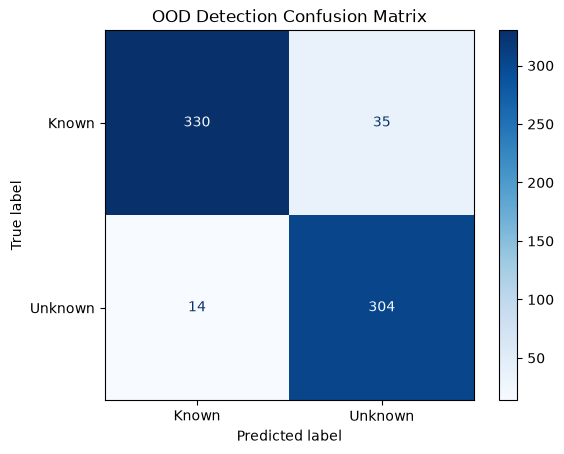

In [30]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Known", "Unknown"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("OOD Detection Confusion Matrix")
plt.show()

DATASET INFORMATION
Evaluation dataset type: <class 'torch.utils.data.dataset.Subset'>
Base dataset type: <class 'torchvision.datasets.folder.ImageFolder'>
Evaluation samples: 365
Real indices: 365

Classes:
['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']

ENERGY INFORMATION
Energy scores: 365
Threshold: -18.040495

OOD RESULTS
Known → Unknown: 35 / 365
Rate: 9.59%

Predictions: 365
Confidences: 365

KNOWN → UNKNOWN SAMPLES
01. True: vanet      | Pred: vanet      | Confidence: 99.97% | Energy: -12.93 | 198165650.jpg
02. True: vanet      | Pred: vanet      | Confidence: 99.63% | Energy: -13.54 | 199158191.jpg
03. True: kamyunet   | Pred: kamyunet   | Confidence: 100.00% | Energy: -17.50 | 216738258.jpg
04. True: savari     | Pred: savari     | Confidence: 100.00% | Energy: -15.82 | 218745573.jpg
05. True: minibus    | Pred: minibus    | Confidence: 99.91% | Energy: -12.58 | 194268546.jpg
06. True: taxi       | Pred: taxi       | Confidence: 99.96% | 

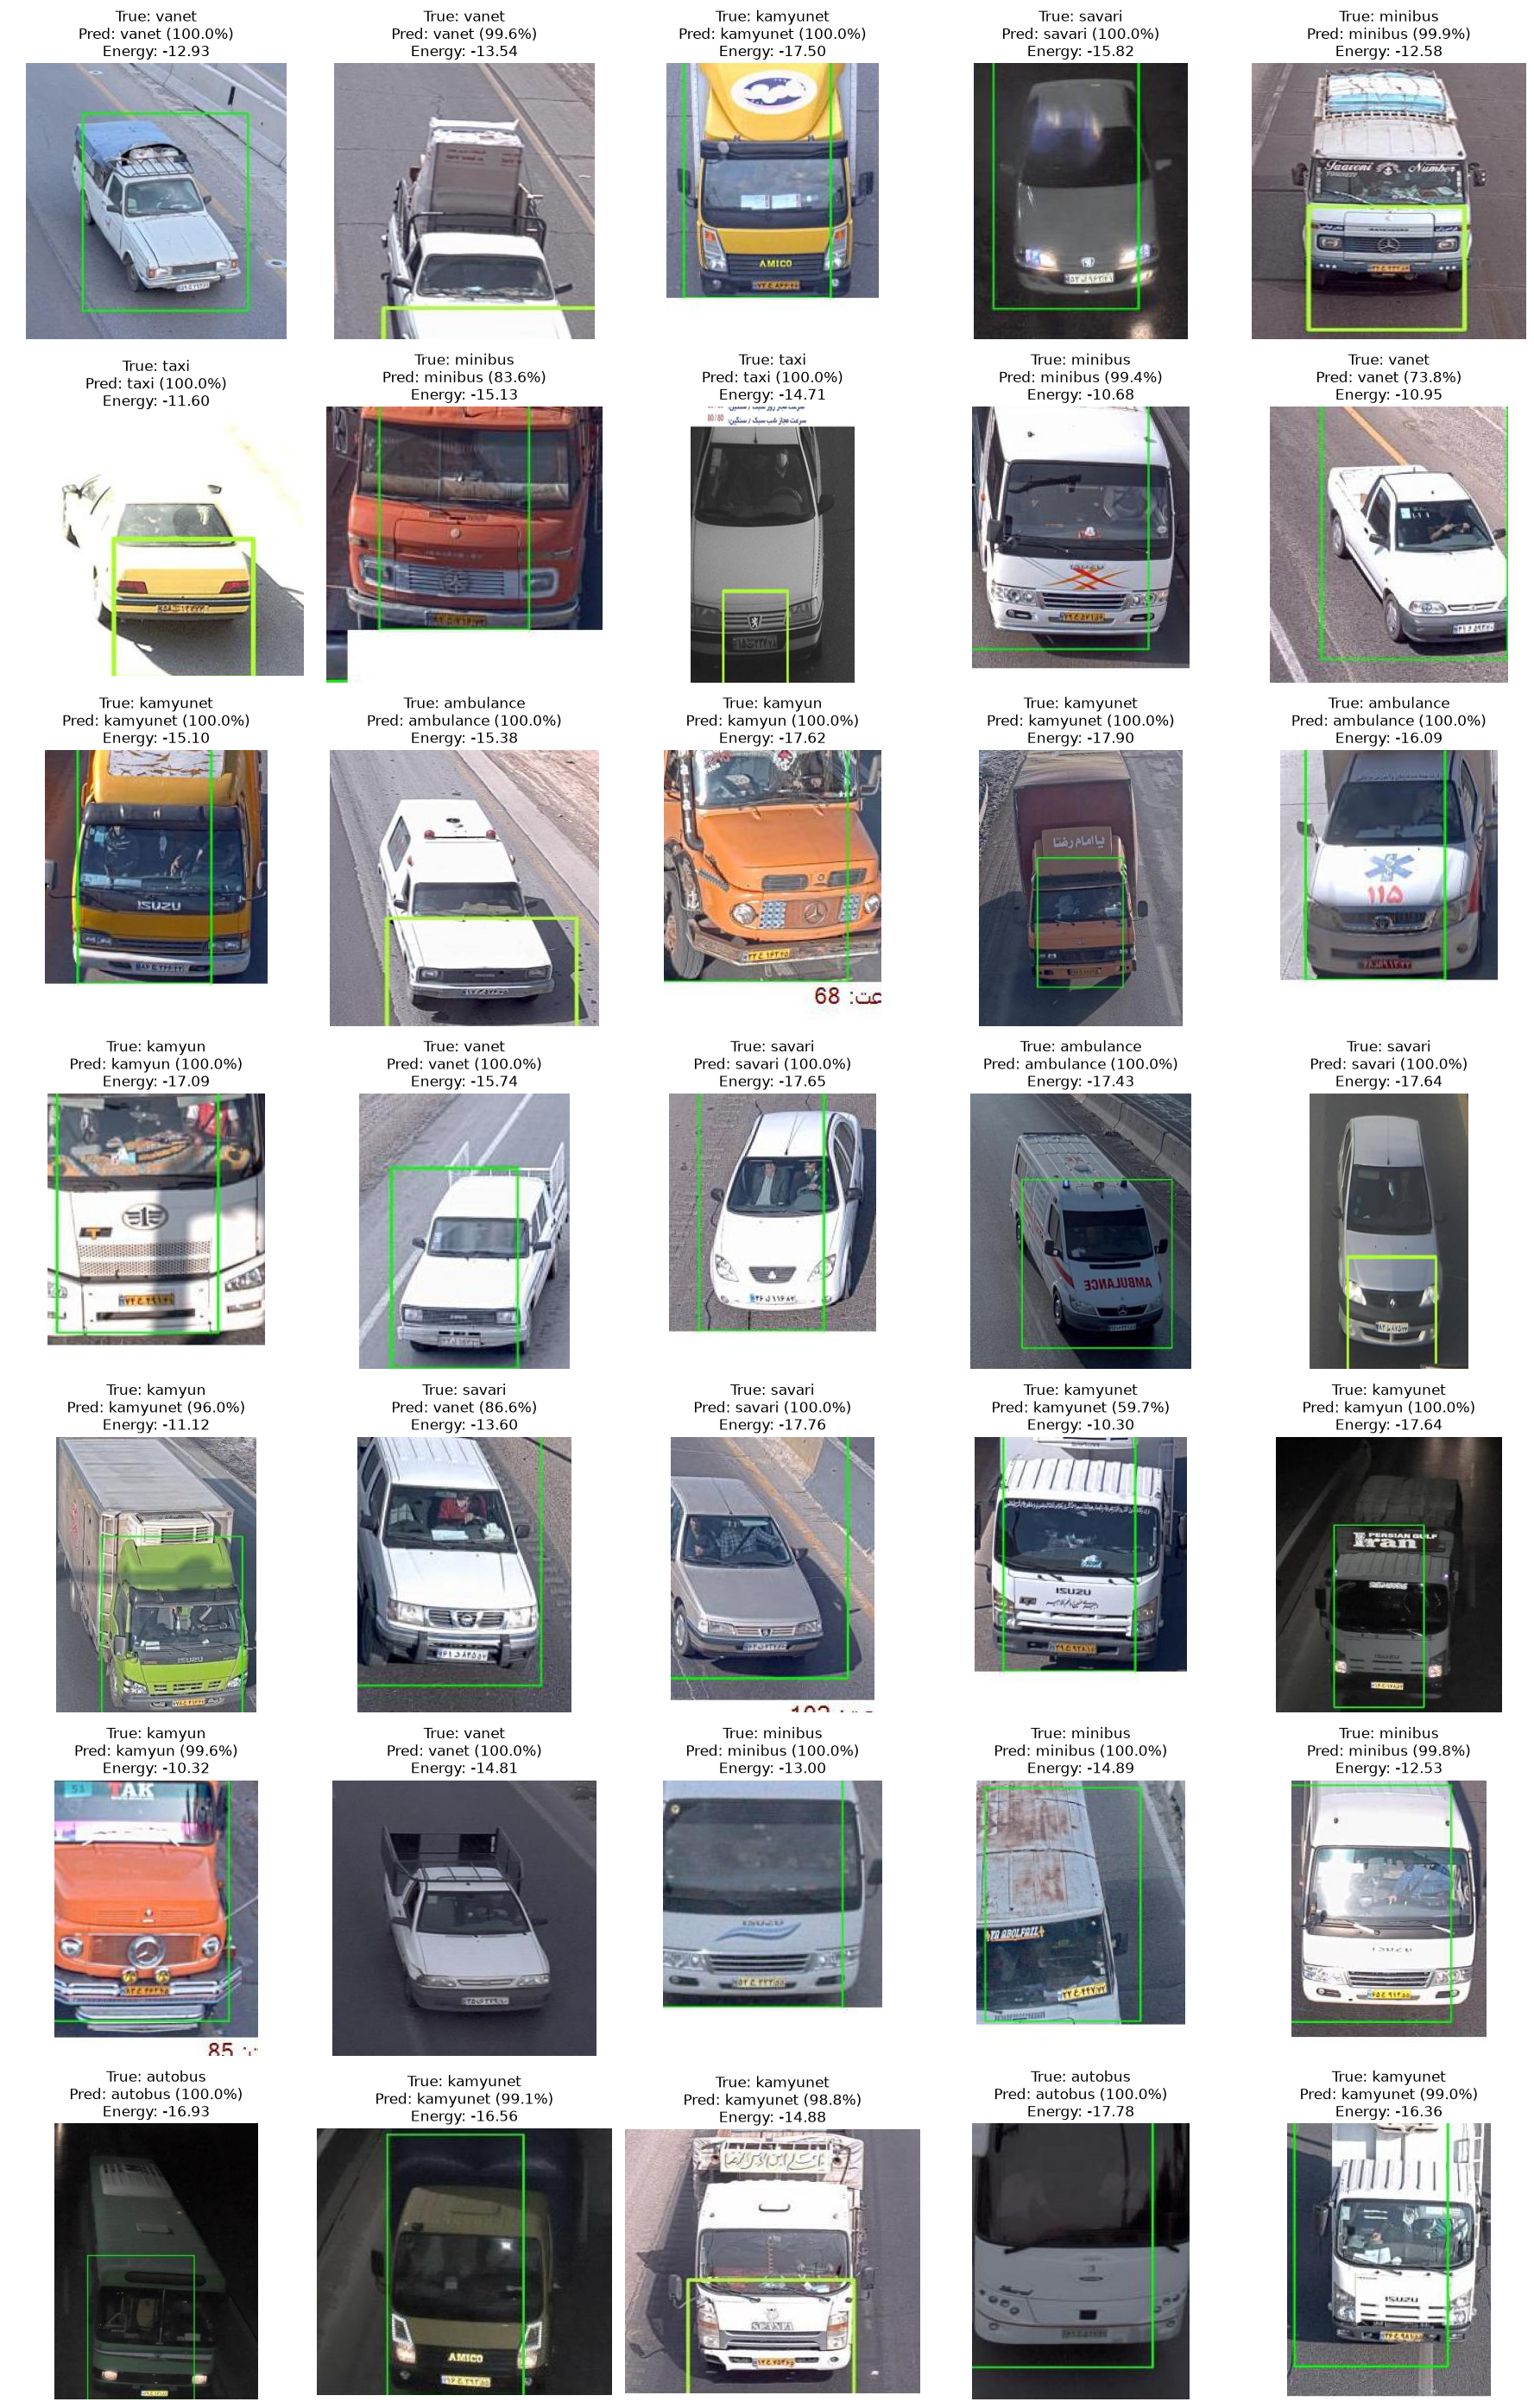

In [31]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torch

best_threshold = -18.040495


def get_original_dataset_and_indices(dataset):

    if hasattr(dataset, "samples"):

        indices = np.arange(len(dataset))

        return dataset, indices

    if hasattr(dataset, "dataset") and hasattr(dataset, "indices"):

        parent_dataset = dataset.dataset
        current_indices = np.array(dataset.indices)

        base_dataset, parent_indices = get_original_dataset_and_indices(
            parent_dataset
        )

        final_indices = parent_indices[current_indices]

        return base_dataset, final_indices

    raise TypeError(
        f"Dataset type is not supported: {type(dataset)}"
    )


eval_dataset = val_eval_loader.dataset

base_dataset, real_indices = get_original_dataset_and_indices(
    eval_dataset
)


print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Evaluation dataset type:", type(eval_dataset))
print("Base dataset type:", type(base_dataset))
print("Evaluation samples:", len(eval_dataset))
print("Real indices:", len(real_indices))

print()
print("Classes:")
print(base_dataset.classes)


print()
print("=" * 70)
print("ENERGY INFORMATION")
print("=" * 70)

print("Energy scores:", len(known_eval_energy))
print("Threshold:", best_threshold)


if len(known_eval_energy) != len(eval_dataset):

    raise ValueError(
        f"Number of Energy scores ({len(known_eval_energy)}) "
        f"does not match evaluation dataset ({len(eval_dataset)})."
    )



wrong_indices = np.where(
    known_eval_energy > best_threshold
)[0]


print()
print("=" * 70)
print("OOD RESULTS")
print("=" * 70)

print(
    f"Known → Unknown: "
    f"{len(wrong_indices)} / {len(known_eval_energy)}"
)

print(
    f"Rate: "
    f"{len(wrong_indices) / len(known_eval_energy) * 100:.2f}%"
)


model.eval()

predictions = []
confidences = []

with torch.no_grad():

    for images, labels in val_eval_loader:

        images = images.to(device)

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

        predictions.extend(
            predicted.cpu().numpy()
        )

        confidences.extend(
            confidence.cpu().numpy()
        )


predictions = np.array(predictions)
confidences = np.array(confidences)


print()
print("Predictions:", len(predictions))
print("Confidences:", len(confidences))

print()
print("=" * 70)
print("KNOWN → UNKNOWN SAMPLES")
print("=" * 70)

for number, idx in enumerate(wrong_indices):

    real_idx = real_indices[idx]

    image_path = base_dataset.samples[real_idx][0]

    true_class_idx = base_dataset.samples[real_idx][1]
    true_class = base_dataset.classes[true_class_idx]

    predicted_class_idx = predictions[idx]
    predicted_class = base_dataset.classes[predicted_class_idx]


    confidence = confidences[idx]

    energy = known_eval_energy[idx]

    print(
        f"{number + 1:02d}. "
        f"True: {true_class:<10} | "
        f"Pred: {predicted_class:<10} | "
        f"Confidence: {confidence:.2%} | "
        f"Energy: {energy:.2f} | "
        f"{os.path.basename(image_path)}"
    )


num_images = len(wrong_indices)

if num_images == 0:

    print("\nNo Known → Unknown samples found.")

else:

    cols = 5
    rows = math.ceil(num_images / cols)

    plt.figure(
        figsize=(18, 4 * rows)
    )

    for i, idx in enumerate(wrong_indices):

        real_idx = real_indices[idx]


        image_path = base_dataset.samples[real_idx][0]


        true_class_idx = base_dataset.samples[real_idx][1]
        true_class = base_dataset.classes[true_class_idx]

        predicted_class_idx = predictions[idx]
        predicted_class = base_dataset.classes[predicted_class_idx]


        confidence = confidences[idx]


        energy = known_eval_energy[idx]


        image = Image.open(
            image_path
        ).convert("RGB")

        plt.subplot(
            rows,
            cols,
            i + 1
        )

        plt.imshow(image)

        plt.title(
            f"True: {true_class}\n"
            f"Pred: {predicted_class} ({confidence:.1%})\n"
            f"Energy: {energy:.2f}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()